# 99 - Showcase: the whole pipeline, end to end, on one company

This notebook is the walkthrough I want to give on the call. Notebooks 12 to 16 each do one job and
each one is long, so rather than reading four of them I have pulled the whole story into a single
narrative here: how I went from **one** Companies House snapshot to a 33-month time series, how every
feature family was computed, how those features turned into targets we can actually predict, and how
the modelling pipeline is put together so that swapping the feature matrix or the model is one line.

Nothing here recomputes anything. Every table and figure below is read straight off the artefacts the
earlier notebooks wrote, so this is a tour of the finished pipeline rather than a re-run of it.

### The running example

Wherever a concept is easier to see on one company than in aggregate, I use the same one throughout:

> **CUBICLE WASHROOM SYSTEMS LIMITED, company number 09919041.**

I picked it because almost everything in the pipeline fires on it at least once. It is a Small
manufacturer, about ten years old, active in all 33 months. It took on new secured borrowing three
separate times inside the panel window. It was a **Lloyds client** at the start of the panel, released
both Lloyds charges in November 2023, borrowed from Shawbrook two months later and from NatWest twice
since, so the entire lender story (client, departure, competitor encroachment, win-back candidate)
plays out on one company. And in February 2026 it won its first public contract, a £597k award from
Bournemouth, Christchurch and Poole Council. It is also sitting right next to the June 2025 hole in
the register, so the gap handling is visible on its rows.

### The map

| step | notebook | what it produced | on disk |
|---|---|---|---|
| 1 | 12 | 33 monthly snapshots, company-month panel | `data/processed/panel/` |
| 2 | 13, 13a | 25 backward-looking delta features | `data/processed/panel_deltas/` |
| 3 | 14 | public contract wins, joined as-of | `data/processed/contracts_asof/` |
| 3b | 14a | wider contract coverage via name matching | `data/processed/contracts_asof_ext/` |
| 3c | 14b | lender identity from the Charges API | `data/processed/lender_panel/` |
| 4 | 15, 15b | four self-labelled targets, sampled matrices | `data/processed/labels/`, `model_matrix/` |
| 5 | 16 | models, SHAP, live scores, run records | `reports/runs/`, `data/processed/scores/` |

The order of this notebook follows that table.

## Setup

Same convention as every other notebook: work from the repo root so the default paths inside `src/`
resolve, let DuckDB do the heavy lifting over the parquet folders, and only pull small results back
into pandas.

In [1]:
import json
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import ch_bulk
from src.features import charges, contracts, lenders, panel
from src.models import targets, train

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)

con = duckdb.connect()
con.execute("PRAGMA disable_progress_bar")
con.execute("PRAGMA threads=6")
con.execute("SET memory_limit='8GB'")
con.execute("SET temp_directory='data/processed/duckdb_tmp'")

PANEL   = (panel.PANEL_DIR / "**" / "*.parquet").as_posix()
DELTA   = (panel.DELTA_DIR / "**" / "*.parquet").as_posix()
ASOF    = (contracts.ASOF_DIR / "**" / "*.parquet").as_posix()
ASOFX   = (contracts.ASOF_EXT_DIR / "**" / "*.parquet").as_posix()
LENDERP = (charges.LENDER_PANEL_DIR / "**" / "*.parquet").as_posix()
LABELS  = (targets.LABEL_DIR / "**" / "*.parquet").as_posix()

EX = "09919041"          # the running example
EX_NAME = "CUBICLE WASHROOM SYSTEMS LIMITED"

# One colour per target, kept consistent with notebook 15b so the figures match.
COLOR = {"lending": "#2c7fb8", "insolvency": "#c0392b",
         "voluntary_exit": "#e08214", "growth": "#31a354"}
NICE = {"lending": "Lending Readiness", "insolvency": "Credit Risk Exposure",
        "voluntary_exit": "Voluntary Exit", "growth": "Growth Signal"}
ORDER = ["lending", "insolvency", "voluntary_exit", "growth"]

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})

print(f"panel months : {panel.FIRST_MONTH} to {panel.LAST_MONTH}")
print(f"features     : {len(targets.FEATURE_COLS)} baseline, {len(targets.FEATURE_COLS_LENDER)} with lender columns")
print(f"targets      : {list(targets.TARGETS)}  (+ {list(targets.LENDER_TARGETS)}, built but untrained)")

panel months : 2023-10-01 to 2026-07-01
features     : 41 baseline, 54 with lender columns
targets      : ['lending', 'insolvency', 'voluntary_exit', 'growth']  (+ ['switching'], built but untrained)


---

# 1. From one monthly download to a 33-month time series

## 1.1 What we had, and why it was not enough

Everything before notebook 12 ran off a single Companies House bulk file, the June 2026 snapshot, and
its filtered descendant `data/processed/filtered_bb_sme_sectors.csv` (1,372,321 active companies in
our three sectors). That file is one row per company and it describes a company **today**. It has two
problems, and they are the reason this whole workstream exists.

1. **No change.** You cannot say "this company's charges tripled in six months" from one photograph,
   and change is the actual buying signal.
2. **Nothing to predict.** SHAP explains a model's predictions, a model needs a target, and a single
   snapshot has no target in it. A time series fixes that in the neatest possible way: the label is
   just a future value of a column we already hold, so the data labels itself and nobody hand-labels
   anything.

Companies House only links the current month on its download page, but the older monthly zips stay on
the server and are reachable by direct URL. Probing found **33 months, Oct 2023 to Jul 2026**, and I
downloaded and kept all of them (about 15 GB of zips). They are a rolling window, so the oldest will
age out of the server eventually and our copy becomes the only one.

In [2]:
# The verified manifest. Filenames are not reliably the 1st of the month, and one month is simply
# absent from the server.
rows, y, m = [], 2023, 10
while (y, m) <= (2026, 7):
    ym = f"{y}-{m:02d}"
    date = next((d for d in ch_bulk.MANIFEST if d.startswith(ym)), None)
    rows.append({"month": ym, "file date on the CH server": date or "MISSING (real hole)"})
    m += 1
    if m > 12:
        y, m = y + 1, 1

manifest = pd.DataFrame(rows)
print(f"{len(ch_bulk.MANIFEST)} snapshots downloaded over {len(manifest)} calendar months")
manifest.T

33 snapshots downloaded over 34 calendar months


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33
month,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07
file date on the CH server,2023-10-04,2023-11-01,2023-12-04,2024-01-01,2024-02-07,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,MISSING (real hole),2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01,2026-01-01,2026-02-01,2026-03-02,2026-04-01,2026-05-01,2026-06-01,2026-07-01


**June 2025 does not exist.** That is not a failed download, it is a hole on the server, and it
dictated a surprising amount of the design further down. Every window in the pipeline had to be made
calendar-aware rather than positional, because a positional "go back three rows" would silently step
over the hole and return a four-month delta with no error and nothing to notice.

## 1.2 The shape: long, not wide

The panel keeps the "one row per company" idea from the old CSV and adds time to it, so it is **one
row per company per month**. About 2.04M companies over 33 months gives **49,556,152 rows**.

The layout you might picture, which we do **not** use:

```
CompanyNumber | charges_Oct23 | charges_Nov23 | ... | charges_Jul26
09919041      | 4             | 4             | ... | 8
```

What we actually store:

```
CompanyNumber | snapshot_date | charges | d_charges_3m
09919041      | 2023-10-01    | 4       | NULL
09919041      | 2023-11-01    | 4       | NULL
...
09919041      | 2026-07-01    | 8       | 1
```

Every company is a block of up to 33 rows. Adding a feature never adds rows, it adds a column, and
the old single-vintage CSV is simply this table filtered to one `snapshot_date`.

Here is the example company's block, straight off the panel.

In [3]:
ex_panel = con.execute(f"""
    SELECT snapshot_date, "CompanyName", "CompanyStatus", sector, segment, size_tier,
           "Mortgages.NumMortCharges"     AS charges,
           "Mortgages.NumMortOutstanding" AS outstanding,
           "Mortgages.NumMortSatisfied"   AS satisfied,
           round(company_age_years, 1)    AS age_years,
           accounts_overdue
    FROM read_parquet('{PANEL}', hive_partitioning=true)
    WHERE "CompanyNumber" = '{EX}'
    ORDER BY snapshot_date
""").df()

print(f"{EX_NAME} ({EX}): {len(ex_panel)} monthly rows, one per snapshot")
ex_panel

CUBICLE WASHROOM SYSTEMS LIMITED (09919041): 33 monthly rows, one per snapshot


,snapshot_date,CompanyName,CompanyStatus,sector,segment,size_tier,charges,outstanding,satisfied,age_years,accounts_overdue
0,2023-10-01,CUBICLE WASHROOM SYSTEMS LIMITED,Active,Manufacturing,Small,Small,4,2,2,7.8,False
1,2023-11-01,CUBICLE WASHROOM SYSTEMS LIMITED,Active,Manufacturing,Small,Small,4,2,2,7.9,False
2,2023-12-01,CUBICLE WASHROOM SYSTEMS LIMITED,Active,Manufacturing,Small,Small,4,0,4,8.0,False
3,2024-01-01,CUBICLE WASHROOM SYSTEMS LIMITED,Active,Manufacturing,Small,Small,4,0,4,8.0,False
4,2024-02-01,CUBICLE WASHROOM SYSTEMS LIMITED,Active,Manufacturing,Small,Small,5,1,4,8.1,False
5,2024-03-01,CUBICLE WASHROOM SYSTEMS LIMITED,Active,Manufacturing,Small,Small,5,1,4,8.2,False
6,2024-04-01,CUBICLE WASHROOM SYSTEMS LIMITED,Active,Manufacturing,Small,Small,5,1,4,8.3,False
7,2024-05-01,CUBICLE WASHROOM SYSTEMS LIMITED,Active,Manufacturing,Small,Small,5,1,4,8.4,False
8,2024-06-01,CUBICLE WASHROOM SYSTEMS LIMITED,Active,Manufacturing,Small,Small,5,1,4,8.5,False
9,2024-07-01,CUBICLE WASHROOM SYSTEMS LIMITED,Active,Manufacturing,Small,Small,5,1,4,8.5,False


Two things to read off that block, both of which matter later.

**`charges` moves three times**: 4 to 5 in Feb 2024, 5 to 7 in Aug 2025, 7 to 8 in May 2026. Those are
the borrowing events that the lending features measure and the lending target predicts.

**`age_years` climbs by 1/12 per month.** That looks trivial and it is actually a correctness check I
care about. The static features are computed with `add_static_features(df, today=snapshot_date)`, so
they say what was true *then*. If I had let them default to `Timestamp.today()`, every historical row
would carry today's age and a "now" would have leaked into the whole panel.

**And there is no 2025-06 row**, because there is no June 2025 file.

## 1.3 Two design decisions that would have quietly ruined everything

**Two passes, not one.** My first instinct was to replay notebook 1's sector filter on every month.
That is wrong: a company can be re-coded out of our SIC sectors without dying, and a per-month filter
would make it vanish from the panel, which looks exactly like a dissolution. So pass 1 collects every
`CompanyNumber` that matches our sectors in *any* month (the universe), and pass 2 emits a row for
every universe member present in a month whatever its status or current sector. Absence from the
panel now means one thing only: gone from the register.

**Keep every status.** Notebook 1 filtered to `Active`, which was right for a prospect list. Replaying
that per month would have deleted every failure event, leaving a panel in which no company ever fails
and a credit-risk model with nothing to learn from. Insolvent firms are not prospects, but they are
exactly the labels we need, so they stay in and `is_active` is applied at scoring time instead.

The table below is those two decisions earning their keep.

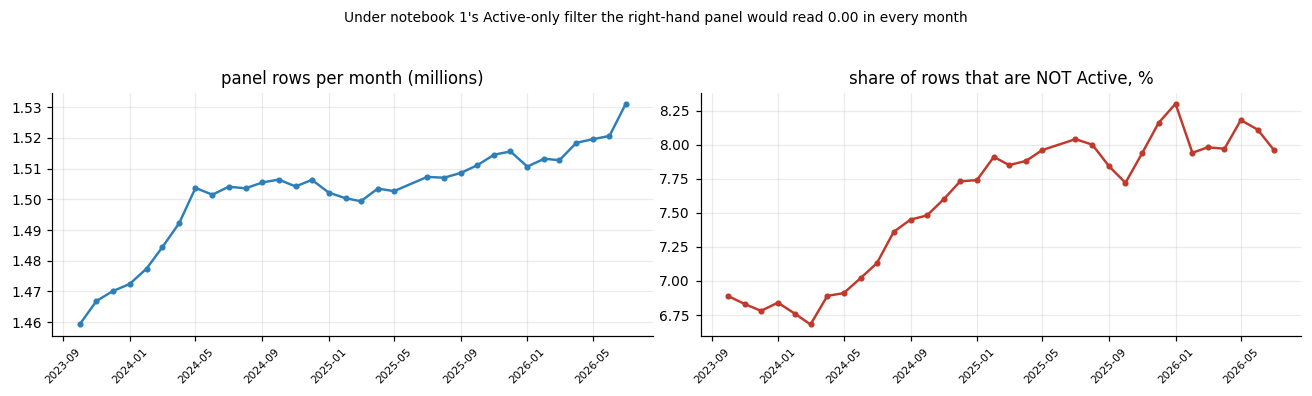

total panel rows: 49,556,152


,snapshot_date,rows,pct_not_active,recoded_out_of_sector
27,2026-02-01,1513203,7.94,29909.0
28,2026-03-01,1512709,7.98,29231.0
29,2026-04-01,1518375,7.97,28436.0
30,2026-05-01,1519532,8.18,27504.0
31,2026-06-01,1520621,8.11,26649.0
32,2026-07-01,1531094,7.96,25891.0


In [4]:
shape = con.execute(f"""
    SELECT snapshot_date,
           count(*)                                                                   AS rows,
           round(100.0 * avg(CASE WHEN NOT is_active THEN 1 ELSE 0 END), 2)           AS pct_not_active,
           sum(CASE WHEN sector IS NULL THEN 1 ELSE 0 END)                            AS recoded_out_of_sector
    FROM read_parquet('{PANEL}', hive_partitioning=true)
    GROUP BY 1 ORDER BY 1
""").df()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].plot(shape["snapshot_date"], shape["rows"] / 1e6, "o-", lw=1.6, ms=3, color="#2c7fb8")
axes[0].set_title("panel rows per month (millions)")
axes[1].plot(shape["snapshot_date"], shape["pct_not_active"], "o-", lw=1.6, ms=3, color="#c0392b")
axes[1].set_title("share of rows that are NOT Active, %")
for ax in axes:
    ax.tick_params(axis="x", rotation=45, labelsize=7)
fig.suptitle("Under notebook 1's Active-only filter the right-hand panel would read 0.00 in every month",
             y=1.04, fontsize=9)
plt.tight_layout(); plt.show()

print(f"total panel rows: {shape['rows'].sum():,}")
shape.tail(6)

The rising non-Active share is the credit-risk signal appearing in the data. `recoded_out_of_sector`
is the two-pass design: those are companies still alive on the register whose SIC no longer maps to
one of our sectors, and a naive per-month filter would have counted every one of them as a death.

**The parity check** is what makes all of this trustworthy, and it is worth restating because it is
the check I ran on day one: the panel's June 2026 partition, filtered back to Active and in-sector,
reproduces `filtered_bb_sme_sectors.csv` exactly. 1,372,321 rows, the identical `CompanyNumber` set,
and matching sector counts (Tech/legal 837,066, Fast growth 320,670, Manufacturing 214,585). The
historical replay is faithful to notebook 1, and the other 32 months are built by the same code path.

---

# 2. Every feature family, and how each one is computed

Notebook 13a walked through the deltas: which raw Companies House column each one comes from, what it
measures, and how to read it. This section does the same thing for the **other three feature
families** I built after that, so the whole 54-column matrix is accounted for in one place.

The four families and where they come from:

In [5]:
families = pd.DataFrame([
    {"family": "level (panel at t)", "n": len(targets.LEVEL_FEATURE_COLS) + len(targets.CATEGORICAL_COLS),
     "source": "CH bulk file, the value in month t", "built in": "nb 12", "module": "src/features/panel.py",
     "artefact": "data/processed/panel/"},
    {"family": "delta (backward)", "n": len(panel.DELTA_FEATURE_COLS),
     "source": "the same column at t and t-3/6/12m", "built in": "nb 13, 13a", "module": "src/features/panel.py",
     "artefact": "data/processed/panel_deltas/"},
    {"family": "contracts (as-of)", "n": len(contracts.ASOF_FEATURE_COLS),
     "source": "Contracts Finder + Find a Tender OCDS", "built in": "nb 14, 14a", "module": "src/features/contracts.py",
     "artefact": "data/processed/contracts_asof/"},
    {"family": "lender (point-in-time)", "n": len(charges.LENDER_FEATURE_COLS) + len(charges.LENDER_CATEGORICAL_COLS),
     "source": "CH Charges API, persons_entitled", "built in": "nb 14b", "module": "src/features/charges.py",
     "artefact": "data/processed/lender_panel/"},
]).set_index("family")
print(f"total: {families['n'].sum()} feature columns "
      f"({len(targets.FEATURE_COLS)} baseline + {len(targets.FEATURE_COLS_LENDER) - len(targets.FEATURE_COLS)} lender)")
families

total: 54 feature columns (41 baseline + 13 lender)


,n,source,built in,module,artefact
family,,,,,
level (panel at t),9,"CH bulk file, the value in month t",nb 12,src/features/panel.py,data/processed/panel/
delta (backward),25,the same column at t and t-3/6/12m,"nb 13, 13a",src/features/panel.py,data/processed/panel_deltas/
contracts (as-of),7,Contracts Finder + Find a Tender OCDS,"nb 14, 14a",src/features/contracts.py,data/processed/contracts_asof/
lender (point-in-time),13,"CH Charges API, persons_entitled",nb 14b,src/features/charges.py,data/processed/lender_panel/


## 2.1 Deltas, in one screen (the recap of notebook 13a)

A delta is always the same shape: **one panel column observed at two points in time**, differenced.
All of them are strictly backward-looking from month `t`, because they are model inputs and the labels
come from the future.

The design point worth repeating is the **month spine**. A positional `LAG(3)` on a panel with a hole
in it is silently wrong: standing in September 2025 and stepping back three rows lands on May, because
June has no row, so a "3-month delta" quietly becomes a four-month one. I tried two other fixes first
(an explicit interval self-join, which spilled 27 GB and never finished, and a lag-with-date-check,
which was never wrong but threw away a year of valid 12-month deltas). What works is building every
company against all 34 calendar months so the missing month exists as an explicit all-NULL row.
`LAG(N)` is then exactly N calendar months back by construction, reaching over the hole lands on the
NULL row, and the delta comes back NULL rather than wrong.

Here it is on the example company.

In [6]:
ex_delta = con.execute(f"""
    SELECT snapshot_date,
           "Mortgages.NumMortCharges" AS charges,
           d_charges_3m, d_charges_6m, d_charges_12m,
           new_charge_events_12m, months_since_last_new_charge,
           months_in_current_status, months_since_last_confstmt,
           accounts_stale_streak_months
    FROM read_parquet('{DELTA}', hive_partitioning=true)
    WHERE "CompanyNumber" = '{EX}'
    ORDER BY snapshot_date
""").df()
ex_delta

,snapshot_date,charges,d_charges_3m,d_charges_6m,d_charges_12m,new_charge_events_12m,months_since_last_new_charge,months_in_current_status,months_since_last_confstmt,accounts_stale_streak_months
0,2023-10-01,4,<NA>,<NA>,<NA>,0.0,<NA>,0,10,0
1,2023-11-01,4,<NA>,<NA>,<NA>,0.0,<NA>,1,11,0
2,2023-12-01,4,<NA>,<NA>,<NA>,0.0,<NA>,2,12,0
3,2024-01-01,4,0,<NA>,<NA>,0.0,<NA>,3,13,0
4,2024-02-01,5,1,<NA>,<NA>,1.0,0,4,2,0
5,2024-03-01,5,1,<NA>,<NA>,1.0,1,5,3,0
6,2024-04-01,5,1,1,<NA>,1.0,2,6,4,0
7,2024-05-01,5,0,1,<NA>,1.0,3,7,5,0
8,2024-06-01,5,0,1,<NA>,1.0,4,8,6,0
9,2024-07-01,5,0,1,<NA>,1.0,5,9,7,0


Read down the `d_charges_3m` column and the mechanics are all visible:

- **It is NULL for the first three months**, because there is no history behind the panel to difference
  against. `d_charges_12m` is NULL for the first year for the same reason.
- **It fires at +1 in Feb, Mar and Apr 2024** and then settles back to 0. One event, three months of a
  three-month window seeing it. That is the lending signal in its raw form.
- **It is NULL in September 2025.** Three months before September is June 2025, which does not exist,
  so the delta refuses to guess rather than silently comparing against May. The neighbouring months are
  fine: August 2025 reaches back to May 2025, which exists, and computes normally.
- **`d_charges_12m` is NULL in June 2026** for the same reason from the other side, and
  `months_since_last_confstmt` shows the healthy annual sawtooth (climbs to 13, drops to 2 when they
  file again). A company that has *stopped* filing shows that line only ever climbing, which is the
  earliest distress tell we have.

## ⭐ 2.2 Public contracts: the raw award, and the as-of aggregation

Everything above comes from one source, the Companies House register, which tells us how a company
**files and borrows** but nothing about whether it is **winning work**. Public procurement is the one
large, free, company-number-keyed signal of new revenue available, and a first public contract win is
a textbook working-capital trigger.

Three things about how this was built.

**Bulk OCDS files, not the API.** Notebook 5 pulled Contracts Finder through the live API and its
`max_batches=60` at `limit=100` silently capped the harvest at 6,000 releases, which is why it ended
up with 2,154 award rows. I take both feeds as bulk OCDS from the Open Contracting Partnership
registry instead, which removes the rate limiting and the cursor paging in one move and makes the
harvest reproducible.

**Two feeds, because procurement publishing split in half in Feb 2025.** The Procurement Act 2023 took
effect on 24 February 2025, and from that date new procurements publish on **Find a Tender** while
**Contracts Finder** keeps only the legacy processes. That is a legal cutover, not a gradual
migration, and it lands squarely in the middle of the panel. Had I joined Contracts Finder alone,
`contracts_won_12m` would decay toward zero from Feb 2025 for reasons that have nothing to do with
company behaviour, and the out-of-time test window is exactly the period it would have poisoned.

**Company numbers only, never names, in the strict set.** The OCDS `parties` block carries a real
Companies House number under the `GB-COH` scheme on about 32% of Contracts Finder suppliers and 11% of
Find a Tender ones. Dropping the rest costs a lot of coverage, and I would rather undercount than
invent a contract win on an innocent company. An undercount is uniform noise; a false positive is a
wrong phone call.

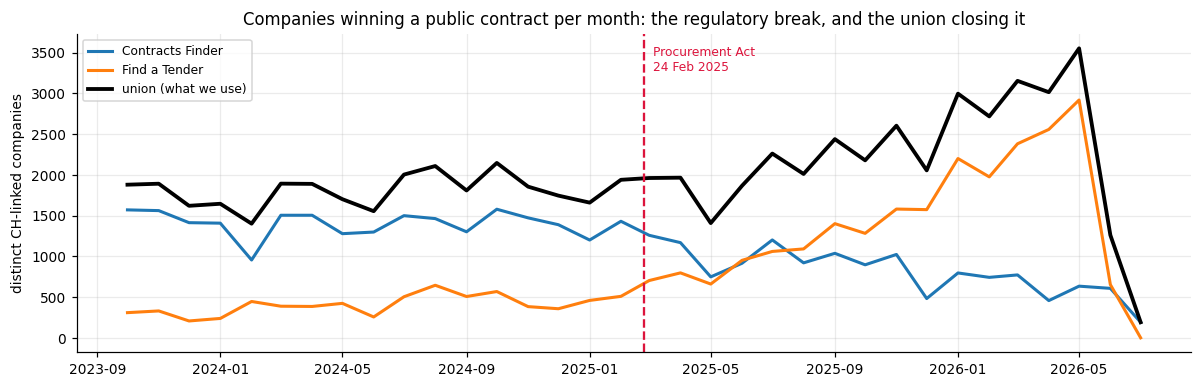

In [7]:
break_df = con.execute(f"""
    SELECT date_trunc('month', publication_date)::DATE AS m, source,
           count(DISTINCT "CompanyNumber") AS winners
    FROM read_parquet('{(contracts.FLAT_PATH).as_posix()}')
    WHERE publication_date >= DATE '2023-10-01'
    GROUP BY 1, 2 ORDER BY 1, 2
""").df()
piv = break_df.pivot(index="m", columns="source", values="winners").fillna(0).astype(int)
piv["UNION"] = piv.sum(axis=1)

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(piv.index, piv["CF"], lw=2, label="Contracts Finder")
ax.plot(piv.index, piv["FTS"], lw=2, label="Find a Tender")
ax.plot(piv.index, piv["UNION"], lw=2.5, color="black", label="union (what we use)")
ax.axvline(pd.Timestamp("2025-02-24"), color="crimson", ls="--", lw=1.5)
ax.text(pd.Timestamp("2025-03-05"), ax.get_ylim()[1] * 0.88, "Procurement Act\n24 Feb 2025",
        color="crimson", fontsize=8)
ax.set_ylabel("distinct CH-linked companies")
ax.set_title("Companies winning a public contract per month: the regulatory break, and the union closing it")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Contracts Finder slides from about 1,500 companies a month to a few hundred, Find a Tender climbs from
about 400 to about 2,900, and the union holds up. One caveat visible at the right-hand edge: the two
registry files were retrieved at different moments, so the last month or two is **censored** by the
harvest watermark. Contract counts fall there because we stopped observing, not because companies
stopped winning. `build_matrix` refuses to train past the watermark; scoring on it is fine.

### From one award row to seven monthly features

Now the actual computation, on the example company. It has exactly one award in the whole dataset.

In [8]:
ex_award = con.execute(f"""
    SELECT source, match_method, buyer_name, publication_date, signature_date,
           award_value_gbp, award_value_share_gbp, num_suppliers_on_award, ocid
    FROM read_parquet('{(contracts.FLAT_PATH).as_posix()}')
    WHERE "CompanyNumber" = '{EX}'
""").df()
ex_award.T

,0
source,FTS
match_method,coh
buyer_name,"Bournemouth, Christchurch and Poole Council"
publication_date,2026-02-05 00:00:00
signature_date,2026-02-02 00:00:00
award_value_gbp,597000.0
award_value_share_gbp,597000.0
num_suppliers_on_award,1
ocid,ocds-h6vhtk-05db83


Note **`publication_date` 2026-02-05 against `signature_date` 2026-02-02**. Everything is gated on the
publication date, never the signature date. A contract can be signed in March and published in May,
and a model standing in March must not be allowed to see it. Using the signature date would leak the
publication lag straight into a model input.

That single row becomes seven columns on every month of the panel, by counting only awards published
**on or before the end of that month**. A static join would stamp this February 2026 win onto a 2024
row, which is the most basic form of leakage there is.

In [9]:
ex_asof = con.execute(f"""
    SELECT snapshot_date, contracts_won_12m, total_value_won_12m, awards_with_value_12m,
           months_since_last_award, d_contracts_12m, ever_won_contract, first_award_in_12m
    FROM read_parquet('{ASOF}', hive_partitioning=true)
    WHERE "CompanyNumber" = '{EX}'
    ORDER BY snapshot_date
""").df()
print("The as-of table is sparse: a company only gets a row from the month its first award was published.")
ex_asof

The as-of table is sparse: a company only gets a row from the month its first award was published.


,snapshot_date,contracts_won_12m,total_value_won_12m,awards_with_value_12m,months_since_last_award,d_contracts_12m,ever_won_contract,first_award_in_12m
0,2026-02-01,1,597000.0,1,0,1,True,True
1,2026-03-01,1,597000.0,1,1,1,True,True
2,2026-04-01,1,597000.0,1,2,1,True,True
3,2026-05-01,1,597000.0,1,3,1,True,True
4,2026-06-01,1,597000.0,1,4,1,True,True
5,2026-07-01,1,597000.0,1,5,1,True,True


The row appears in **February 2026** and not one month earlier, which is the as-of gate doing its job.
`months_since_last_award` then counts up from 0, and `first_award_in_12m` stays true for twelve months.

`first_award_in_12m` is the one I actually care about commercially. Notebook 5's EDA found that 78% of
winning companies win exactly once, and a company that has just landed its **first** public contract
usually needs working capital to deliver it and is far less likely to be locked in with a competitor
bank than a repeat mega-winner. Our example is precisely that company.

Two health warnings that belong on any slide this reaches. `months_since_last_award` stays **NULL**
for a company that never won anything, deliberately, because "never happened" is not a zero. And
`total_value_won_12m` is dominated by framework ceilings: the median award is £124k, but 2,767 awards
are priced at £1bn or more and hold 95% of all the value in the dataset (the worst is a framework that
stamps £150bn on each of its suppliers). `contracts_won_12m` and `first_award_in_12m` are the
trustworthy columns.

## 2.3 Name matching: can we widen the contract coverage safely?

The strict `GB-COH` join reaches about **1% of the panel**, so before committing to it I checked
whether that could be widened. Two routes.

**Route 1, a lookup table from `GB-COH` to the other identifier flavours, is a dead end**, and I can
say exactly why: the OCDS `additionalIdentifiers` block carries a `GB-PPON` on only 1.5% of unmatched
suppliers, and the party id is *derived from* the identifier rather than independent of it (a supplier
appears as `GB-COH-09889191` when it published a company number and `GB-FTS-68641` when it did not),
so there is no stable internal id that exists in both states to bridge them.

**Route 2, matching on name plus postcode, works at a measurable cost.** The key is the normalised
name (uppercase, strip punctuation and legal-form suffixes) plus a postcode, recovered from
`address.postalCode` on Find a Tender and by regex out of the free-text `streetAddress` on Contracts
Finder, which fills it for about 87% of them.

The part I am most pleased with is that the precision here is **measured, not asserted**. Every
supplier that published a `GB-COH` identifier is a labelled example: throw the identifier away, run
the matcher on name and postcode alone, and compare its answer to the truth over about 100k labelled
records. Name alone is ~88% precise, name plus postcode is **~92%**, and if you restrict to suppliers
whose true company is in our universe it is ~98%. The residual error is almost entirely one bounded
failure mode: a supplier whose real company sits outside our three sectors, whose name happens to
match an in-universe company uniquely.

Two decisions came out of that. Match against the **full register** rather than our universe, so the
construction company that is not in our universe still matches its own name and the key is rejected as
ambiguous rather than mis-assigned. And **never break a tie**: picking one of two candidates would be
a coin flip recorded as a fact.

In [10]:
# What the two contract feature sets cost and buy. Nothing overwrote anything: the strict set is
# exactly as notebook 14 verified it, and the extended set sits beside it.
mm = con.execute(f"""
    SELECT match_method, count(*) AS award_rows, count(DISTINCT "CompanyNumber") AS companies
    FROM read_parquet('{(contracts.FLAT_EXT_PATH).as_posix()}')
    GROUP BY 1 ORDER BY 2 DESC
""").df()
print(mm.to_string(index=False))

rows = []
for label, d in [("strict (GB-COH only)", contracts.ASOF_DIR), ("extended (+ name+postcode)", contracts.ASOF_EXT_DIR)]:
    p5 = (panel.DELTA_DIR / "snapshot_date=2026-05-01" / "*.parquet").as_posix()
    a5 = (d / "snapshot_date=2026-05-01" / "*.parquet").as_posix()
    r = con.execute(f"""
        SELECT count(*) AS panel_rows, count(c."CompanyNumber") AS with_contract
        FROM read_parquet('{p5}') d LEFT JOIN read_parquet('{a5}') c USING ("CompanyNumber")
    """).fetchone()
    rows.append({"feature set": label, "panel rows": r[0], "companies with a contract": r[1],
                 "coverage": r[1] / r[0]})
cov = pd.DataFrame(rows)
print()
print(cov.to_string(index=False, formatters={"coverage": "{:.2%}".format}))
print(f"\ncoverage multiple: {cov['coverage'].iloc[1] / cov['coverage'].iloc[0]:.2f}x")

match_method  award_rows  companies
         coh      172929      44518
     name_pc       80694      16957

               feature set  panel rows  companies with a contract coverage
      strict (GB-COH only)     1519532                      15556    1.02%
extended (+ name+postcode)     1519532                      24158    1.59%

coverage multiple: 1.55x


So the extended set is a **1.55x** coverage gain bought with about 8% wrong rows. I checked that the
signal survives the extra noise rather than assuming it: the separation between contract winners and
everyone else on "took new secured borrowing in 12m" moves from about 7.5x to about 6.9x, so it
dilutes visibly but does not collapse.

That is why both directories exist and neither replaced the other. Step 6 can A/B them by pointing at
a different directory, and the out-of-time AUC decides. One rule regardless of the result: **anything
shown to a relationship manager is filtered to `match_method = 'coh'`.** A model can absorb 8% label
noise; a phone call to a company about a contract it never won cannot.

## ⭐ 2.4 Lender identity: who actually banks this company

This is the feature family that closes the biggest gap in the pipeline. Everything above describes the
**company**. Nothing in it describes **who banks the company**, and the three areas Lloyds asked about
are defined on exactly that axis: Growth is "not ours, will need a product", Attrition is "ours and
leaving", Maintenance is "ours and staying".

The unlock is that Companies House charges are **append-only and dated**. Every charge carries
`created_on`, `satisfied_on`, a status and `persons_entitled[].name`, which is the lender. So one API
pass today reconstructs the entire 33-month lender history retrospectively, with no historical
downloads at all. I harvested every company that has ever held a charge in any of the 33 snapshots:
**158,684 companies, 558,693 charges, 25.4 hours**, zero 404s and zero duplicates.

Here is the raw material for the example company, which is the whole lender story on one screen.

In [11]:
ex_charges = con.execute(f"""
    SELECT charge_id, created_on, satisfied_on, status, lender_name, lender_group, is_lbg
    FROM read_parquet('{(charges.FLAT_PATH).as_posix()}')
    WHERE "CompanyNumber" = '{EX}'
    ORDER BY created_on
""").df()
ex_charges

,charge_id,created_on,satisfied_on,status,lender_name,lender_group,is_lbg
0,09919041-1,2015-12-18,2019-06-20,fully-satisfied,Valtegra Fund I S.C.Sp. Acting by Its General ...,unclassified,False
1,09919041-2,2016-01-13,2019-06-20,fully-satisfied,Bibby Financial Services LTD (As Security Trus...,asset_invoice_finance,False
2,09919041-3,2018-01-15,2023-11-15,fully-satisfied,Lloyds Bank Commercial Finance LTD,lbg,True
3,09919041-4,2020-06-03,2023-11-15,fully-satisfied,Lloyds Bank PLC,lbg,True
4,09919041-5,2024-01-31,2025-07-18,fully-satisfied,Shawbrook Bank Limited,challenger_bank,False
5,09919041-7,2025-07-11,NaT,outstanding,Mml UK Advisor LLP (As Security Trustee),trustee_spv,False
6,09919041-6,2025-07-11,NaT,outstanding,National Westminster Bank PLC as Security Trustee,natwest,False
7,09919041-8,2026-03-30,NaT,outstanding,National Westminster Bank PLC as Security Trus...,natwest,False


Read that as a relationship:

- Two **Lloyds** charges (2018 and 2020), both **satisfied on 15 November 2023**. We were their
  secured lender and then we were not.
- **Shawbrook**, a challenger bank, lends in January 2024, two months after our charges were released.
- **NatWest** twice since, July 2025 and March 2026, and NatWest is now their primary lender.

That is a full switch, an encroachment and a win-back candidate in one company, and none of it is
visible in the bulk file, which only ever carries charge *counts*.

### The taxonomy

558,693 charges carry 572,776 `persons_entitled` rows across **78,708 distinct names**, free text typed
by whoever filed the MR01, so "Lloyds Bank plc", "Lloyds Bank PLC as security agent" and "Lloyds Bank
Commercial Finance Limited" are three strings and one bank. I collapsed them onto institutions with an
**ordered dictionary of regex rules** in `src/features/lenders.py`, not with fuzzy matching. Bank
lending is extremely concentrated and the population of lenders is small, stable and knowable, so an
explicit rule list is cheaper and, more importantly, auditable: a client can read the rule that decided
their company is ours.

Three ordering decisions do the real work, since the rules are first-match-wins: `lbg_retail` (Halifax,
Black Horse, MBNA) runs before `lbg` so retail is not silently counted as commercial lending;
`natwest` runs before `lbg` so "The Royal Bank of Scotland plc" cannot be read as Bank of Scotland; and
the bank groups run before the trustee/SPV catch-all so "Barclays Security Trustee Limited" is Barclays.
Legacy names map to whoever owns the book today, because the question is "who does this company borrow
from", not "what was that entity called in 1996".

In [12]:
flat = pd.read_parquet(charges.FLAT_PATH)
coverage = lenders.coverage(flat)
print(f"{len(flat):,} (charge, lender) rows, {flat['lender_name'].nunique():,} distinct lender names\n")
coverage

572,776 (charge, lender) rows, 78,708 distinct lender names



,rows,share
lender_group,,
unclassified,128666,0.224636
natwest,93927,0.163986
lbg,69408,0.121178
barclays,68968,0.120410
hsbc,68270,0.119191
other_bank,34250,0.059796
challenger_bank,30707,0.053611
trustee_spv,26496,0.046259
asset_invoice_finance,23127,0.040377


**77.5% of charge-lender rows fall into a named group.** The headline for the growth conversation is
sitting in that table: NatWest is the largest holder in the BB/SME register at 16.4%, then LBG at
12.1%, Barclays 12.0% and HSBC 11.9%. The big four hold about half the register and **NatWest holds a
third more of it than we do**.

The unclassified 22.5% is not a failure, it is the long tail of individuals, landlords, directors
lending to their own company and one-off SPVs. Nothing left in the top of that tail is a bank.

### ⭐ The point-in-time replay

A charge is **outstanding at month `t`** if and only if `created_on <= t AND (satisfied_on IS NULL OR
satisfied_on > t)`. That one predicate, run against every month of the panel, reconstructs the whole
lender history without a single extra API call.

Two details. The as-of gate is the **first** of the month, not the last, because the panel row for
month `t` is the register as it stood at the start of `t`, and gating on month end would put up to 30
days of future charge activity into a feature row. And **June 2025 needs no special case here**: this
table is built from charge event dates over a full calendar spine, not from register snapshots, so the
missing snapshot is simply a month the panel never asks about.

In [13]:
ex_lender = con.execute(f"""
    SELECT snapshot_date, n_charges_outstanding, n_lbg_charges_outstanding, is_lbg_client,
           lbg_share_of_outstanding, n_competitor_lenders, primary_lender_group,
           months_since_last_lbg_satisfaction, competitor_entered_12m,
           lbg_charge_satisfied_6m, competitor_charge_created_6m, ever_lbg_client
    FROM read_parquet('{LENDERP}', hive_partitioning=true)
    WHERE "CompanyNumber" = '{EX}'
    ORDER BY snapshot_date
""").df()
ex_lender

,snapshot_date,n_charges_outstanding,n_lbg_charges_outstanding,is_lbg_client,lbg_share_of_outstanding,n_competitor_lenders,primary_lender_group,months_since_last_lbg_satisfaction,competitor_entered_12m,lbg_charge_satisfied_6m,competitor_charge_created_6m,ever_lbg_client
0,2023-10-01,2,2,True,1.0,0,lbg,<NA>,False,False,False,True
1,2023-11-01,2,2,True,1.0,0,lbg,<NA>,False,False,False,True
2,2023-12-01,0,0,False,NaN,0,NaN,1,False,True,False,True
3,2024-01-01,0,0,False,NaN,0,NaN,2,False,True,False,True
4,2024-02-01,1,0,False,0.0,1,challenger_bank,3,True,True,True,True
5,2024-03-01,1,0,False,0.0,1,challenger_bank,4,True,True,True,True
6,2024-04-01,1,0,False,0.0,1,challenger_bank,5,True,True,True,True
7,2024-05-01,1,0,False,0.0,1,challenger_bank,6,True,True,True,True
8,2024-06-01,1,0,False,0.0,1,challenger_bank,7,True,False,True,True
9,2024-07-01,1,0,False,0.0,1,challenger_bank,8,True,False,True,True


Every column in that table is derived from the three raw fields in the charge list above, and you can
watch the relationship end in it:

- **Oct and Nov 2023**: `is_lbg_client` true, `lbg_share_of_outstanding` 1.0. Sole-banked with us.
- **Dec 2023**: the flag flips to false, the month **after** the 15 November satisfaction, which is the
  point-in-time check. `months_since_last_lbg_satisfaction` starts counting.
- **Feb 2024**: Shawbrook arrives, `competitor_entered_12m` fires, and both `lbg_charge_satisfied_6m`
  and `competitor_charge_created_6m` are true at once. That pair is the **switch signature**: either
  one alone is deleveraging or ordinary extra borrowing, and only together do they mean a defection.
- **Aug 2025 onward**: NatWest is the primary lender and `n_competitor_lenders` is 2.
- **`ever_lbg_client` stays true for all 33 months.** That is the win-back universe, and a lapsed
  client is a much warmer call than a cold prospect.

Verification on this table was seven checks, and the one I would put in front of anyone sceptical is
the leakage test: truncate the charge history at 1 Jan 2025 (delete later creations, blank later
satisfactions), rebuild the whole lender panel from the truncated history, and compare the 2025-01
partition against the one built from the full history. They are identical row for row and column for
column, so no feature at `t` reaches forward. The reconciliation check is the other good one: the
API-derived outstanding count matches the bulk file's `Mortgages.NumMortOutstanding` for **97.7%** of
companies exactly and 99.3% within one, and the 2.2% that disagrees is one-directional (part-satisfied
charges, which the bulk file excludes and my predicate counts), which is the safe direction.

---

# 3. From features to targets: how the dummy variables are built

Everything so far produced **features**. Not one of them is a target, and until notebook 15 there was
nothing to predict. This is where the time series pays for itself: the future of the panel labels its
own past, so nobody hand-labels anything.

The rule everything depends on is one line:

> **Features come from month `t`. Labels come from `t+1 ... t+H`. Never from `t` itself.**

Break it and you get a model with a beautiful AUC that is worthless in production, because in
production `t+1` has not happened yet. The cleanest way I have found to explain the three objects is by
which way in time they look.

| object | built in | direction | example |
|---|---|---|---|
| raw column | nb 12 | none | `Mortgages.NumMortCharges`, the value in month `t` |
| **delta** (a feature) | nb 13 | looks **backward** from `t` | `d_charges_3m`, the change over the last 3 months |
| **label** (a target) | nb 15 | looks **forward** from `t` | `y_lending`, did the count go up in the next 3 months |

## 3.1 ⭐ The four labels, and two traps that changed the definitions

In [14]:
anatomy = pd.DataFrame([
    {"target": "lending", "index": "Lending Readiness", "H": 3,
     "fires when": "Mortgages.NumMortCharges is higher at any month in t+1..t+H",
     "reads as": "took on new secured borrowing"},
    {"target": "insolvency", "index": "Credit Risk Exposure", "H": 6,
     "fires when": "status enters liquidation / administration / receivership / voluntary arrangement",
     "reads as": "a genuine credit event"},
    {"target": "voluntary_exit", "index": "Voluntary Exit", "H": 6,
     "fires when": "status becomes 'Active - Proposal to Strike off'",
     "reads as": "winding down by choice"},
    {"target": "growth", "index": "Growth Signal", "H": 12,
     "fires when": "size band moves up the Micro < Small < Medium < Large ladder",
     "reads as": "grew past a filing threshold"},
]).set_index("target")
anatomy

,index,H,fires when,reads as
target,,,,
lending,Lending Readiness,3,Mortgages.NumMortCharges is higher at any mont...,took on new secured borrowing
insolvency,Credit Risk Exposure,6,status enters liquidation / administration / r...,a genuine credit event
voluntary_exit,Voluntary Exit,6,status becomes 'Active - Proposal to Strike off',winding down by choice
growth,Growth Signal,12,size band moves up the Micro < Small < Medium ...,grew past a filing threshold


All four are conditioned on **Active at `t`**, because a company already in liquidation is not a
prospect and asking whether it will become insolvent is meaningless.

**Trap 1: "non-Active" is not distress.** The original plan defined the risk label as "Active at `t`,
non-Active by `t+H`". That runs at about 4%, and roughly **90% of it is voluntary strike-off**: dormant
micro-companies quietly closing. That is not a credit event and no bank wants it in a risk model.
Filtering to genuine insolvency drops it to about 0.34%, so I model both separately. Blending them
would let the loud label drown the important one.

I also renamed the strike-off label. It was called Attrition until 26 July, and Lloyds uses that word
for a specific thing: a client moving their banking to a competitor so we can try to win them back. A
company striking itself off is not a relationship to recover, it is a dead company. Shipping our label
under their word would have meant answering a question they never asked while appearing to answer the
one they did. Hence **Voluntary Exit**, and attrition is reserved for provider switching, which is
exactly what the lender features in section 2.4 make measurable.

**Trap 2: `segment` is not a size ladder.** It mixes real sizes (Micro, Small, Medium, Large) with
filing states (No Filings, Dormant, Subsidiary, Unknown), and a naive "segment changed" is about 13%
at 12 months, most of it `No Filings` to `Micro` churn, which is a filing event rather than growth. The
panel carries `tier_rank`, which ranks only the four real tiers and leaves the filing buckets NULL, and
companies with no rank are excluded from the growth label rather than squeezed in somewhere.

**Origins are quarterly**, which makes the 3-month lending windows non-overlapping, so each
company-quarter is an independent observation rather than fifteen near-copies of the same one.

## 3.2 The arithmetic, on the example company

Here is the label being built, with the forward window printed next to it so the arithmetic can be
checked by eye. `max_charges_next_3m` is a DuckDB `RANGE` frame keyed on the calendar date
(`INTERVAL 1 MONTH FOLLOWING` to `INTERVAL 3 MONTH FOLLOWING`), not a positional offset, for exactly
the same reason the deltas use a spine: a positional frame would reach an extra month past the June
2025 hole.

In [15]:
ex_lab = con.execute(f"""
    WITH obs AS (
        SELECT snapshot_date AS m, "Mortgages.NumMortCharges" AS charges, tier_rank
        FROM read_parquet('{DELTA}', hive_partitioning=true)
        WHERE "CompanyNumber" = '{EX}'
    ),
    fwd AS (
        SELECT m, charges, tier_rank,
               max(charges) OVER (ORDER BY m
                   RANGE BETWEEN INTERVAL 1 MONTH FOLLOWING AND INTERVAL 3 MONTH FOLLOWING)
                   AS max_charges_next_3m,
               max(tier_rank) OVER (ORDER BY m
                   RANGE BETWEEN INTERVAL 1 MONTH FOLLOWING AND INTERVAL 12 MONTH FOLLOWING)
                   AS max_tier_next_12m
        FROM obs
    )
    SELECT l.origin_month,
           f.charges AS charges_at_t, f.max_charges_next_3m, l.y_lending,
           f.tier_rank AS tier_at_t,  f.max_tier_next_12m,  l.y_growth,
           l.y_insolvency, l.y_voluntary_exit
    FROM read_parquet('{LABELS}', hive_partitioning=true) l
    JOIN fwd f ON f.m = l.origin_month
    WHERE l."CompanyNumber" = '{EX}'
    ORDER BY l.origin_month
""").df()
ex_lab

,origin_month,charges_at_t,max_charges_next_3m,y_lending,tier_at_t,max_tier_next_12m,y_growth,y_insolvency,y_voluntary_exit
0,2023-10-01,4,4,0,2,2,0,0,0
1,2024-01-01,4,5,1,2,2,0,0,0
2,2024-04-01,5,5,0,2,2,0,0,0
3,2024-07-01,5,5,0,2,2,0,0,0
4,2024-10-01,5,5,0,2,2,0,0,0
5,2025-01-01,5,5,0,2,2,0,0,0
6,2025-04-01,5,5,0,2,2,0,0,0
7,2025-07-01,5,7,1,2,2,0,0,0
8,2025-10-01,7,7,0,2,2,<NA>,0,0
9,2026-01-01,7,7,0,2,2,<NA>,0,0


Everything in the four label columns is now readable straight off the row.

- **`y_lending = 1` at the 2024-01 origin.** Five charges appear by February, against four at the
  origin, so the switch flips. Note the label is attached to **January**, the month we would have been
  standing in, not February when the charge landed. That is exactly the row a relationship manager
  would have wanted flagged.
- **Positive again at 2025-07 and 2026-04**, for the Aug 2025 and May 2026 events. Three borrowing
  events in 33 months, three positive quarters, every other origin a clean 0.
- **`y_growth = 0` throughout.** The company sits at `tier_rank` 2 (Small) and never moves up.
- **The trailing NULLs are the horizon, not missing data.** At the 2026-04 origin a 6-month window
  would need data to October 2026 and the register stops at July 2026. NULL means "cannot say yet", and
  the labels never fill that with a 0, which would quietly teach the model that nothing ever happens at
  the end of the panel.

One more definitional point that comes up every time. Voluntary exit is measured as an **event
anywhere in the window**, not as a **state at `t+H`**. For lending and insolvency the two are nearly
the same, but about half of all strike-off proposals are **withdrawn** once a company files its overdue
accounts, so the event definition runs at 7 to 8% where the state definition runs at 3.5%. I ship the
event, because a company that went overdue, received a strike-off notice and scrambled to file was in
difficulty and was a company you could still have helped, and because a state read off a single month
is hostage to that month existing, which given June 2025 is not a property I want any label to depend on.

## 3.3 Are the labels sane? Base rates, and are they stable

Base rate is the plainest number in the project: the share of rows where the label is 1. It earns its
keep twice. As a **sanity check**, it is the cheapest possible test that a label means what I think it
means (a "6-month insolvency rate" coming out at 20% is a broken definition, not a subtle bug, and this
is how I caught the original label being 90% strike-off). And as **the floor any model has to beat**:
if 0.34% of companies fail, a call list picked at random is right 0.34% of the time.

I also want it flat across origins, because step 6 trains on early quarters and tests on late ones. If
the rate drifted, a test score would be partly measuring the calendar rather than the model.

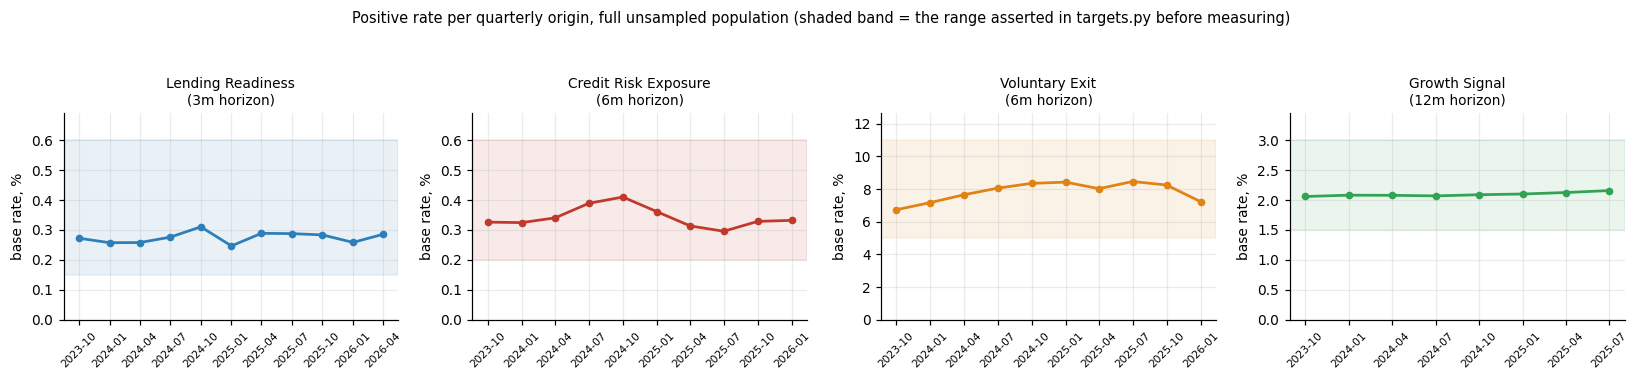

target,growth,insolvency,lending,voluntary_exit
origin_month,,,,
2023-10-01,2.054,0.325,0.272,6.723
2024-01-01,2.076,0.324,0.257,7.160
2024-04-01,2.074,0.340,0.257,7.640
2024-07-01,2.064,0.388,0.275,8.043
2024-10-01,2.084,0.409,0.310,8.336
2025-01-01,2.096,0.360,0.246,8.411
2025-04-01,2.121,0.313,0.288,8.011
2025-07-01,2.153,0.295,0.287,8.450
2025-10-01,NaN,0.328,0.283,8.236


In [16]:
rates = targets.base_rates()
pivot = rates.pivot(index="origin_month", columns="target", values="base_rate")

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, t in zip(axes, ORDER):
    s = pivot[t].dropna() * 100
    lo, hi = [b * 100 for b in targets.EXPECTED_BASE_RATES[t]]
    ax.axhspan(lo, hi, color=COLOR[t], alpha=0.10)
    ax.plot(s.index, s.values, "o-", color=COLOR[t], lw=1.8, ms=4)
    ax.set_title(f"{NICE[t]}\n({targets.TARGETS[t][1]}m horizon)", fontsize=9)
    ax.set_ylabel("base rate, %")
    ax.set_ylim(0, max(hi, s.max()) * 1.15)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
fig.suptitle("Positive rate per quarterly origin, full unsampled population "
             "(shaded band = the range asserted in targets.py before measuring)", y=1.06, fontsize=9.5)
plt.tight_layout(); plt.show()

(pivot * 100).round(3)

Flat, all four, and inside the bands I wrote down **before** measuring. Lending sits between 0.25% and
0.31% across eleven origins with no trend, insolvency wanders between 0.29% and 0.41%, growth creeps
from 2.05% to 2.15% over two years. There is no regime change hiding in this panel, so an out-of-time
split is measuring the model and not the calendar.

## 3.4 Why four indices and not one score

This is the design decision most likely to be challenged, so it is measured rather than argued. If the
labels were largely the same event wearing different hats, one model would be simpler and better. I
measure it with **lift**: among companies positive on label B, how many times more likely are they to
be positive on label A than a company picked at random. Lift of 1 means independent.

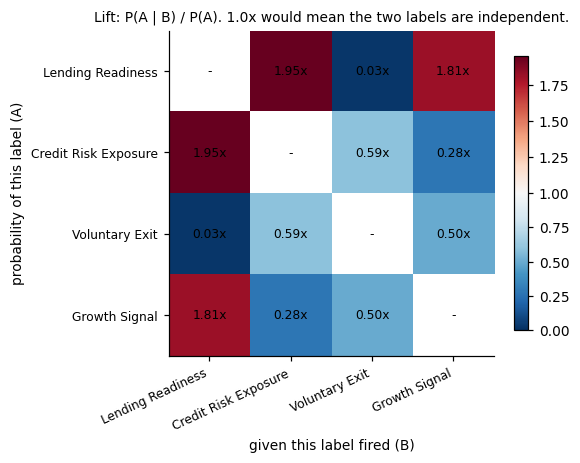

In [17]:
ycols = {t: targets.TARGETS[t][0] for t in ORDER}
pairs = []
for a in ORDER:
    for b in ORDER:
        ca, cb = ycols[a], ycols[b]
        pairs.append(f"""
            SELECT '{a}' AS a, '{b}' AS b,
                   avg({ca}::DOUBLE) AS p_a,
                   avg(CASE WHEN {cb} = 1 THEN {ca}::DOUBLE END) AS p_a_given_b,
                   count(*) FILTER (WHERE {ca} = 1 AND {cb} = 1) AS both
            FROM read_parquet('{LABELS}', hive_partitioning=true)
            WHERE {ca} IS NOT NULL AND {cb} IS NOT NULL
        """)
ov = con.execute(" UNION ALL ".join(pairs)).df()
ov["lift"] = ov["p_a_given_b"] / ov["p_a"]
lift = ov.pivot(index="a", columns="b", values="lift").loc[ORDER, ORDER]

fig, ax = plt.subplots(figsize=(5.4, 4.4))
from matplotlib.colors import TwoSlopeNorm
m = lift.values.astype(float)
im = ax.imshow(np.where(np.eye(4, dtype=bool), np.nan, m), cmap="RdBu_r",
               norm=TwoSlopeNorm(vmin=0, vcenter=1, vmax=np.nanmax(np.where(np.eye(4, dtype=bool), np.nan, m))))
for i in range(4):
    for j in range(4):
        ax.text(j, i, "-" if i == j else f"{m[i, j]:.2f}x", ha="center", va="center", fontsize=8)
ax.set_xticks(range(4)); ax.set_xticklabels([NICE[t] for t in ORDER], rotation=25, ha="right", fontsize=8)
ax.set_yticks(range(4)); ax.set_yticklabels([NICE[t] for t in ORDER], fontsize=8)
ax.set_xlabel("given this label fired (B)"); ax.set_ylabel("probability of this label (A)")
ax.set_title("Lift: P(A | B) / P(A). 1.0x would mean the two labels are independent.", fontsize=9)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

Not one pair is close to being the same label.

- **Insolvency and voluntary exit are 0.59x.** They are both "the company stops being normal", they
  share a six-month horizon, and a company that proposes a strike-off is *less* likely than average to
  enter genuine insolvency. This is the pair I most needed to check, because the original plan merged
  them.
- **Lending goes with insolvency (1.95x) and with growth (1.81x), and is almost mutually exclusive with
  voluntary exit (0.03x).** Only 74 companies in the whole panel took on a new charge and proposed to
  strike themselves off in the same window. Obvious once said out loud, and a strong validation that
  both labels measure what they claim.
- **Borrowing precedes both good and bad outcomes.** That is a real finding, and it is the argument for
  showing Lending Readiness and Credit Risk Exposure side by side rather than netting them into one
  number.

## 3.5 ⭐ The sampling step, and the one column step 6 must not lose

The labels table is the real world: about 1.4M rows per origin, of which 0.34% are insolvency
positives. Keeping 1.4M negatives to teach a model about 4,000 positives is mostly wasted compute, so
the modelling matrix keeps **every positive and downsamples negatives to 10x**. Negatives are selected
by a **hash of the company number** rather than a random draw, so the sample is reproducible without
threading a seed through DuckDB and stays consistent for a company across origins.

The price is that the matrix looks like a world where 9% of companies go insolvent. Ranking survives
that untouched; rates do not, and every predicted probability comes out roughly 30x too high. That is
what `neg_keep_rate`, carried on every row, is for.

In [18]:
compare = []
for t, (col, _) in targets.TARGETS.items():
    pop = con.execute(f"""SELECT count({col}) AS rows, avg({col}::DOUBLE) AS rate
                          FROM read_parquet('{LABELS}', hive_partitioning=true)""").df().iloc[0]
    mat = con.execute(f"""SELECT count(*) AS rows, avg(y::DOUBLE) AS rate, avg(neg_keep_rate) AS keep
                          FROM read_parquet('{(targets.MATRIX_DIR / t / "**" / "*.parquet").as_posix()}',
                                            hive_partitioning=true)""").df().iloc[0]
    compare.append({"target": t, "population rows": int(pop["rows"]), "true base rate": pop["rate"],
                    "matrix rows": int(mat["rows"]), "sampled rate": mat["rate"],
                    "avg neg keep rate": mat["keep"], "shrunk by": pop["rows"] / mat["rows"]})

pd.DataFrame(compare).set_index("target").style.format(
    {"true base rate": "{:.3%}", "sampled rate": "{:.1%}", "avg neg keep rate": "{:.3f}",
     "shrunk by": "{:.0f}x", "population rows": "{:,}", "matrix rows": "{:,}"})

,population rows,true base rate,matrix rows,sampled rate,avg neg keep rate,shrunk by
target,,,,,,
lending,"15,244,182",0.274%,"457,941",9.1%,0.028,33x
insolvency,"13,846,845",0.341%,"520,142",9.1%,0.035,27x
voluntary_exit,"13,846,845",7.826%,"11,917,730",9.1%,0.854,1x
growth,"7,213,562",2.091%,"1,657,611",9.1%,0.214,4x


Insolvency shrinks 27-fold and lending 33-fold, and **not one positive was dropped**; the entire
reduction is negatives we chose not to carry. The sampled rate lands at about 9% for all four, which is
1/11, exactly what "ten negatives per positive" should give. Voluntary exit barely shrinks, because at
a 7.8% base rate there are already only about twelve negatives per positive.

To turn a predicted probability from the sampled world back into a real one:

`p_true = p_sampled * w / (1 - p_sampled + p_sampled * w)`, with `w` the negative keep rate.

Skip it and the ranking is still fine, but every number is a lie by a factor of about 30, which is
exactly the sort of thing that ends up in a slide.

---

# 4. ⭐ One company, every feature and every target, in one table

This is the table I would put on the slide. It is the example company at the **2025-07 origin**, which
I picked because it is one of its positive lending quarters, with all 54 features on the left and all
four labels on the right, grouped by where each column came from.

Everything on the feature side is knowable on 1 July 2025. Everything on the label side happened after
it. That boundary is the entire pipeline in one picture.

In [19]:
ORIGIN = "2025-07-01"

feat_row = con.execute(f"""
    SELECT d.*,
           coalesce(c.contracts_won_12m, 0)      AS contracts_won_12m,
           coalesce(c.total_value_won_12m, 0)    AS total_value_won_12m,
           coalesce(c.awards_with_value_12m, 0)  AS awards_with_value_12m,
           c.months_since_last_award,
           coalesce(c.d_contracts_12m, 0)        AS d_contracts_12m,
           coalesce(c.ever_won_contract, false)  AS ever_won_contract,
           coalesce(c.first_award_in_12m, false) AS first_award_in_12m,
           coalesce(l.n_charges_outstanding, 0)        AS n_charges_outstanding,
           coalesce(l.n_lbg_charges_outstanding, 0)    AS n_lbg_charges_outstanding,
           coalesce(l.is_lbg_client, false)            AS is_lbg_client,
           l.lbg_share_of_outstanding,
           coalesce(l.n_distinct_lenders, 0)           AS n_distinct_lenders,
           coalesce(l.n_competitor_lenders, 0)         AS n_competitor_lenders,
           l.months_since_last_lbg_charge_created,
           l.months_since_last_lbg_satisfaction,
           coalesce(l.competitor_entered_12m, false)   AS competitor_entered_12m,
           coalesce(l.lbg_charge_satisfied_6m, false)  AS lbg_charge_satisfied_6m,
           coalesce(l.competitor_charge_created_6m, false) AS competitor_charge_created_6m,
           coalesce(l.ever_lbg_client, false)          AS ever_lbg_client,
           l.primary_lender_group
    FROM read_parquet('{(panel.DELTA_DIR / ("snapshot_date=" + ORIGIN) / "*.parquet").as_posix()}') d
    LEFT JOIN read_parquet('{(contracts.ASOF_DIR / ("snapshot_date=" + ORIGIN) / "*.parquet").as_posix()}') c
           USING ("CompanyNumber")
    LEFT JOIN read_parquet('{(charges.LENDER_PANEL_DIR / ("snapshot_date=" + ORIGIN) / "*.parquet").as_posix()}') l
           USING ("CompanyNumber")
    WHERE d."CompanyNumber" = '{EX}'
""").df().iloc[0]

label_row = con.execute(f"""
    SELECT y_lending, y_insolvency, y_voluntary_exit, y_growth
    FROM read_parquet('{LABELS}', hive_partitioning=true)
    WHERE "CompanyNumber" = '{EX}' AND origin_month = DATE '{ORIGIN}'
""").df().iloc[0]

FAMILY = {}
for c in targets.LEVEL_FEATURE_COLS + targets.CATEGORICAL_COLS:
    FAMILY[c] = "1. level (panel at t)"
for c in panel.DELTA_FEATURE_COLS:
    FAMILY[c] = "2. delta (backward from t)"
for c in contracts.ASOF_FEATURE_COLS:
    FAMILY[c] = "3. contracts (as-of t)"
for c in charges.LENDER_FEATURE_COLS + charges.LENDER_CATEGORICAL_COLS:
    FAMILY[c] = "4. lender (point-in-time t)"

card = pd.DataFrame(
    [{"family": FAMILY[c], "column": c, "value": feat_row[c]} for c in targets.FEATURE_COLS_LENDER]
    + [{"family": "5. TARGETS (from t+1 .. t+H)", "column": targets.ALL_TARGETS[t][0]
        + f"  (H={targets.TARGETS[t][1]}m)", "value": label_row[targets.TARGETS[t][0]]} for t in ORDER]
).set_index(["family", "column"])

print(f"{EX_NAME} ({EX}) at origin {ORIGIN}: "
      f"{len(targets.FEATURE_COLS_LENDER)} features and {len(ORDER)} labels")
card

CUBICLE WASHROOM SYSTEMS LIMITED (09919041) at origin 2025-07-01: 54 features and 4 labels


value
family                       column                                               
1. level (panel at t)        Mortgages.NumMortCharges                            5
                             Mortgages.NumMortOutstanding                        1
                             Mortgages.NumMortSatisfied                          4
                             company_age_years                                 9.5
                             debt_ratio                                        0.2
                             accounts_overdue                                False
                             tier_rank                                           2
2. delta (backward from t)   d_charges_3m                                        0
                             d_charges_6m                                        0
                             d_charges_12m                                       0
                             d_outstanding_3m                                    0
                             d_outstanding_6m                                    0
                             d_outstanding_12m                                   0
                             d_satisfied_12m                                     0
                             debt_ratio_trend_12m                              0.0
                             new_charge_events_12m                             0.0
                             months_since_last_new_charge                       17
                             status_changed                                   <NA>
                             months_in_current_status                           21
                             ever_distressed_before                          False
                             segment_upgraded_12m                            False
                             segment_downgraded_12m                          False
                             months_since_segment_change                        21
                             accounts_overdue_streak_months                      0
                             accounts_stale_streak_months                        0
                             confstmt_late                                   False
                             days_to_next_accounts_due                          91
                             months_since_last_accounts_filing                  19
                             months_since_last_confstmt                          7
                             sic_changed_12m                                 False
                             name_changed_12m                                False
                             postcode_changed_12m                            False
3. contracts (as-of t)       contracts_won_12m                                   0
                             total_value_won_12m                               0.0
                             awards_with_value_12m                               0
                             months_since_last_award                          <NA>
                             d_contracts_12m                                     0
                             ever_won_contract                               False
                             first_award_in_12m                              False
1. level (panel at t)        sector                                  Manufacturing
                             segment                                         Small
4. lender (point-in-time t)  n_charges_outstanding                               1
                             n_lbg_charges_outstanding                           0
                             is_lbg_client                                   False
                             lbg_share_of_outstanding                          0.0
                             n_distinct_lenders                                  1
                             n_competitor_lenders                                1
          

Walking that card top to bottom, this is the company the pipeline sees on 1 July 2025:

- **Level.** Five charges, one outstanding, four satisfied, ten years old, Small (`tier_rank` 2),
  accounts not overdue. A perfectly ordinary small manufacturer.
- **Delta.** `d_charges_12m` is 0 and `new_charge_events_12m` is 0, so the Feb 2024 borrowing has now
  aged out of the trailing year. Nothing is late, the filing cadence is healthy.
- **Contracts.** All zeros and a NULL recency, because their first award is still seven months in the
  future. This is the as-of gate refusing to leak it.
- **Lender.** One outstanding charge, none of it ours, one competitor lender (Shawbrook),
  `ever_lbg_client` **true** and `months_since_last_lbg_satisfaction` at 20. In one line: a lapsed
  Lloyds client, currently banked by a challenger, twenty months after we lost them.
- **Targets.** `y_lending = 1`. Within three months they took on the NatWest charge. That is the row a
  lending-readiness model is supposed to find, and everything to the left of it is what it had to go on.

One footnote worth knowing when reading the matrices directly: this company appears in
`model_matrix/lending` at only three origins, the three where `y = 1`. Its negative rows were dropped
by the 1:10 downsampling, which is the sampling from section 3.5 showing up at the level of a single
company.

---

# 5. The step 6 pipeline, and why it is built to be swapped

Notebook 16 is the modelling step, and after the supervisor call on 27 July I rewrote it so that the
things we will want to vary are one line each rather than an edit. Fernando asked for a reusable
scikit-learn pipeline, an effortless way to add a model family, an interpretable set plus a neural
network, proper validation where there are hyperparameters, and SHAP where it earns its keep. This
section is the shape that came out of that.

There are **three independent axes** we compare along, and before the rewrite each was a separate
keyword argument threaded through six functions, which had to agree or the run silently did the wrong
thing (a lender matrix read with the baseline feature list just drops the lender columns, no error).

| axis | options today |
|---|---|
| matrix | `model_matrix/` or `model_matrix_lender/`, strict or extended contracts |
| feature set | `FEATURE_COLS` (41) or `FEATURE_COLS_LENDER` (54) |
| model set | any subset of the `MODELS` registry |

They are now tied together in one frozen `RunConfig`, which makes the illegal combinations
unrepresentable and makes a run reproducible from a single value. That value is also what gets written
to the run's `manifest.json`, so "which matrix produced this?" is a question with an answer on disk
rather than in my memory.

In [20]:
from dataclasses import fields

print("RunConfig fields (one deliberate deviation from the baseline each):")
for f in fields(train.RunConfig):
    print(f"  {f.name}")

print("\nThe configs defined today:")
for cfg in (train.BASELINE, train.REFACTOR, train.LENDER):
    print(f"  {cfg.tag:<9} matrix={str(cfg.matrix_dir):<38} {len(cfg.cols())} features  "
          f"cats={cfg.cats()}")

print("\nThe model registry. Adding a family is one dict entry:")
for name, spec in train.MODELS.items():
    print(f"  {name:<9} explainer={spec.explainer:<7} max_rows={spec.max_rows}  "
          f"early_stopping={spec.early_stopping}")

RunConfig fields (one deliberate deviation from the baseline each):
  tag
  matrix_dir
  eval_dir
  feature_cols
  categorical_cols
  target_names
  models
  contracts_dir
  lender_dir

The configs defined today:
  baseline  matrix=data/processed/model_matrix            41 features  cats=['sector', 'segment']
  refactor  matrix=data/processed/model_matrix            41 features  cats=['sector', 'segment']
  lender    matrix=data/processed/model_matrix_lender     54 features  cats=['sector', 'segment', 'primary_lender_group']

The model registry. Adding a family is one dict entry:
  lightgbm  explainer=tree    max_rows=None  early_stopping=True
  logistic  explainer=linear  max_rows=500000  early_stopping=False
  mlp       explainer=kernel  max_rows=300000  early_stopping=False


So the whole of "re-run everything against the lender matrix" is:

```python
CFG = train.LENDER          # instead of train.BASELINE
```

and the whole of "add a random forest" is one `ModelSpec` entry in `train.MODELS`. `run_target` loops
over the registry, the feature list is read from `CFG` rather than copied, and the origin grid for each
target is read off that target's own partitions on disk rather than from a shared assumption, so a
target sitting on a different base population (like `switching`, which is conditioned on holding a
Lloyds charge rather than on being Active) does not need any of it changed.

## 5.1 The split, which is not `train_test_split`

A random split is wrong here in two independent ways. **Company leakage**: each company appears at up
to eleven origins, so a random split puts some of its rows in train and the rest in test and the model
can memorise the company. **Time leakage**: it mixes 2026 rows into training while testing on 2024, so
the model sees the future, which in production it never does.

So: train on early origins, test on late ones, with an **embargo** in between. A training row at origin
`t` carries a label that resolves over `t+1 ... t+H`, so if the first test origin sits inside that
window the model was trained on the answer to its own exam. Every origin where `first_test - t < H` is
dropped.

In [21]:
CFG = train.BASELINE
splits = {t: train.split_origins(t, CFG) for t in CFG.target_names}
for s in splits.values():
    print(s.describe())
    print()

lending (H=3m)
  train   : 2024-10, 2025-01, 2025-04, 2025-07, 2025-10
  embargo : -  (dropped, labels resolve inside test)
  test    : 2026-01, 2026-04
  early-origin filter applied: True

insolvency (H=6m)
  train   : 2024-10, 2025-01, 2025-04
  embargo : 2025-07  (dropped, labels resolve inside test)
  test    : 2025-10, 2026-01
  early-origin filter applied: True

voluntary_exit (H=6m)
  train   : 2024-10, 2025-01, 2025-04
  embargo : 2025-07  (dropped, labels resolve inside test)
  test    : 2025-10, 2026-01
  early-origin filter applied: True

growth (H=12m)
  train   : 2023-10, 2024-01, 2024-04
  embargo : 2024-07, 2024-10, 2025-01  (dropped, labels resolve inside test)
  test    : 2025-04, 2025-07
  early-origin filter applied: False



Three things to read off that.

**Lending loses nothing to the embargo.** Its horizon is 3 months and origins are quarterly, so
consecutive origins are already exactly `H` apart. That was the whole point of quarterly origins back
in step 5, and it is why lending gets five training origins where insolvency gets three.

**Growth had to give up the early-origin filter.** `FIRST_FULL_ORIGIN` (2024-10) is the first month
where the 12-month deltas are actually formed rather than NULL for calendar reasons, and I would rather
train past it, because that missingness lands entirely in train and never in test and is exactly the
sort of artefact a tree will split on and then be unable to use. But a 12-month horizon means the
embargo eats three origins, and honouring the filter too would leave none, so `split_origins` drops the
filter automatically and **records that it did**. Worth remembering when reading growth's numbers.

**precision@N is measured on the unsampled population.** The training matrix has negatives downsampled
10:1, so precision@100 computed on it would be inflated by roughly the enrichment factor. ROC-AUC
survives negative downsampling; PR-AUC and precision@N do not, and precision@N is the headline metric
because a relationship manager works a finite call list. So the test origins are rebuilt with no
downsampling at all before anything is measured.

## 5.2 What came out

In [22]:
runs = train.load_runs()
cols = ["tag", "target", "model", "n_features", "base_rate", "roc_auc", "pr_auc",
        "precision_at_100", "precision_at_500"]
runs[cols].style.format({"base_rate": "{:.3%}", "roc_auc": "{:.4f}", "pr_auc": "{:.4f}",
                         "precision_at_100": "{:.1%}", "precision_at_500": "{:.1%}"})

,tag,target,model,n_features,base_rate,roc_auc,pr_auc,precision_at_100,precision_at_500
0,baseline,lending,lightgbm,41,0.271%,0.8767,0.0567,55.0%,28.2%
1,baseline,lending,logistic,41,0.271%,0.8615,0.0403,18.0%,15.0%
2,baseline,insolvency,lightgbm,41,0.329%,0.7615,0.0169,19.0%,12.2%
3,baseline,insolvency,logistic,41,0.329%,0.7324,0.0119,3.0%,5.8%
4,baseline,voluntary_exit,lightgbm,41,7.728%,0.7929,0.3512,83.0%,84.8%
5,baseline,voluntary_exit,logistic,41,7.728%,0.7704,0.3104,6.0%,29.6%
6,baseline,growth,lightgbm,41,2.137%,0.7620,0.0578,22.0%,20.2%
7,baseline,growth,logistic,41,2.137%,0.7290,0.0468,7.0%,9.8%


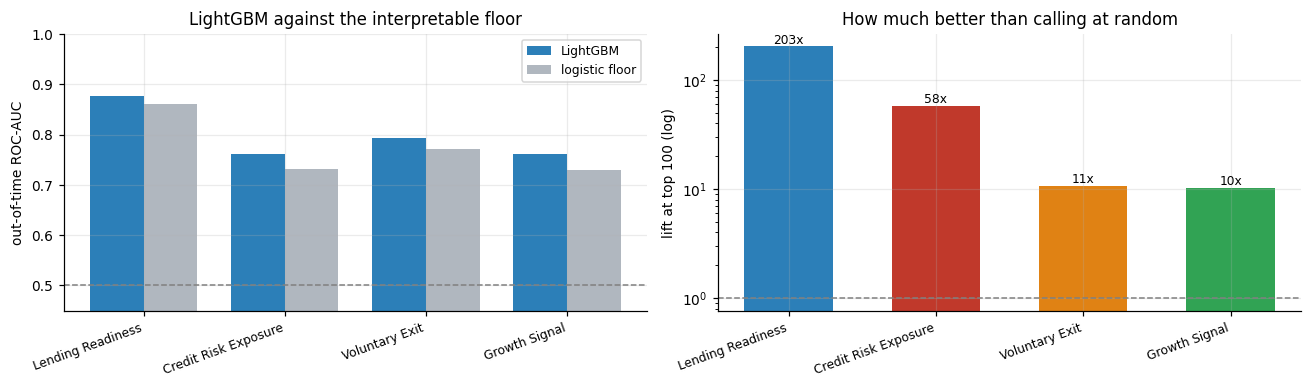

In [23]:
lgb = runs[runs.model == "lightgbm"].set_index("target").loc[ORDER]
log = runs[runs.model == "logistic"].set_index("target").loc[ORDER]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
x = np.arange(4); w = 0.38
axes[0].bar(x - w/2, lgb["roc_auc"], w, label="LightGBM", color="#2c7fb8")
axes[0].bar(x + w/2, log["roc_auc"], w, label="logistic floor", color="#b0b7bf")
axes[0].axhline(0.5, color="grey", ls="--", lw=1); axes[0].set_ylim(0.45, 1.0)
axes[0].set_xticks(x); axes[0].set_xticklabels([NICE[t] for t in ORDER], rotation=20, ha="right", fontsize=8)
axes[0].set_ylabel("out-of-time ROC-AUC"); axes[0].set_title("LightGBM against the interpretable floor")
axes[0].legend(fontsize=8)

lift = lgb["precision_at_100"] / lgb["base_rate"]
axes[1].bar(x, lift, 0.6, color=[COLOR[t] for t in ORDER])
axes[1].set_yscale("log"); axes[1].axhline(1, color="grey", ls="--", lw=1)
axes[1].set_xticks(x); axes[1].set_xticklabels([NICE[t] for t in ORDER], rotation=20, ha="right", fontsize=8)
axes[1].set_ylabel("lift at top 100 (log)"); axes[1].set_title("How much better than calling at random")
for i, v in enumerate(lift):
    axes[1].text(i, v, f"{v:.0f}x", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

The headline numbers, all out of time on the unsampled population:

- **Lending Readiness: ROC-AUC 0.877, precision@100 of 55%, which is 203x the 0.271% base rate.** Of
  our top 100 picks, 55 took on new secured borrowing within three months. That is a call list.
- **Credit Risk Exposure: 0.762, precision@100 19%, 58x.** The hardest of the four, which makes sense:
  it is rarer, slower, and the public register is the last place to hear about it.
- **Voluntary Exit: 0.793, precision@500 85%.** High base rate, so the lift is small but the list is
  almost all correct.
- **Growth Signal: 0.762, precision@100 22%, 10x.**

The logistic floor loses on every target, and by enough that the boosting is clearly earning its
complexity: 1.5 to 4 points of ROC-AUC and a far larger gap on precision@100, which is where the
non-linearity actually pays. That was the question the floor was fitted to answer. I also ran GroupKFold
by company as a secondary check, and the gaps against the out-of-time numbers are small and all in the
same direction (+0.004 to +0.021), so nothing here is riding a period effect.

**On the neural network.** The MLP was added to the registry after the supervisor call and its job is
not to win. On insolvency the order is logistic < MLP < LightGBM, so the network does buy something
over the linear floor, which says there is genuine non-linearity the floor is leaving on the table, but
it does not catch the boosting. That is the expected answer for tabular data of this shape, and it
gives a more honest story than "complex beats simple": the winner is the model that is complex **in the
right way for the data**, and its explanations happen to be exact and cheap.

## 5.3 SHAP, and where it actually earns its keep

SHAP only ever runs on LightGBM in this pipeline, and that is deliberate rather than lazy. For a linear
model the SHAP value of feature *j* is just `coef_j * (x_j - E[x_j])`, a rescaling of a number I can
read straight off the model, so the logistic model is read through its coefficients. For LightGBM there
is no such number and `TreeExplainer` recovers one **exactly** in seconds. For the MLP there is no
shortcut at all and it falls back to `KernelExplainer`, which is sampled, approximate and about a
thousand times slower.

| model | explanation | exact? | cost for 100k rows |
|---|---|---|---|
| logistic | read `coef_` | exact, and free | instant |
| LightGBM | `TreeExplainer` | exact | seconds |
| MLP | `KernelExplainer` | sampled approximation | hours (measured: 20 rows in 2.3s) |

That middle row is the reason the boosted model is the one going into production. Not simply that it
scores best out of time, but that it scores best **and** an RM can be handed the three reasons behind
any individual company's score without a compute budget.

In [24]:
imp = pd.concat([
    pd.read_csv(train.shap_importance_path(t, "baseline")).head(8)
      .assign(target=t, rank=range(1, 9))
    for t in ORDER
])
imp.pivot(index="rank", columns="target", values="feature")[ORDER]

target,lending,insolvency,voluntary_exit,growth
rank,,,,
1,Mortgages.NumMortCharges,segment,months_since_last_confstmt,tier_rank
2,segment,company_age_years,accounts_stale_streak_months,segment
3,sector,months_since_last_accounts_filing,days_to_next_accounts_due,months_since_last_accounts_filing
4,company_age_years,months_since_last_confstmt,company_age_years,months_since_segment_change
5,days_to_next_accounts_due,days_to_next_accounts_due,months_since_last_accounts_filing,Mortgages.NumMortCharges
6,months_since_last_confstmt,Mortgages.NumMortCharges,segment,days_to_next_accounts_due
7,postcode_changed_12m,segment_upgraded_12m,confstmt_late,company_age_years
8,sic_changed_12m,sector,sector,months_in_current_status


These land where notebook 15b's univariate AUCs predicted they would, which is a good sign that nothing
odd happened between the two.

- **Lending is a size-and-existing-debt story.** `Mortgages.NumMortCharges` first, then `segment` and
  `sector`. Companies that already carry charges take on more. Honest, but it means a raw top-N list is
  large leveraged companies first, and an SME desk needs the ranking done **within** a size band. I
  would rather find that here than after someone has worked the list.
- **Voluntary exit is a filing-behaviour story.** `months_since_last_confstmt` and
  `accounts_stale_streak_months` at the top. This is the inversion I find most satisfying in the whole
  project: in a cross-sectional model those features leak, because a company that has stopped filing is
  *already* in trouble. In a panel, measured at `t` and predicting a proposal at `t+6`, they become
  leading indicators. That is one of the clearest arguments for having built a time series at all.
- **Insolvency leans on `company_age_years` and the filing recencies**, and no single feature is strong.
  It is the target where the model earns its keep by combining weak signals.
- **Growth is dominated by `tier_rank`, and that is partly a ceiling effect**: a Large company cannot be
  upgraded, so the label is mechanically impossible at the top of the ladder. Worth interrogating rather
  than celebrating.

I also cross-checked SHAP directions against the logistic coefficients, measuring direction as the
Spearman correlation between a feature's **value** and its **own SHAP value** rather than the mean
signed SHAP value, which is not a direction at all and can average to anything for a non-monotone
feature. Most agree. Insolvency has the most disagreements, and they are the legitimate kind: a
logistic coefficient is a *partial* effect holding everything else fixed, and with features as
correlated as `d_charges_3m`, `d_charges_6m` and `d_charges_12m` a partial effect can honestly flip
sign against the marginal relationship SHAP shows.

## 5.4 Scoring the live month, and the example company's own scores

Score wide and cheap, enrich narrow and expensive. Every active company in the latest panel month gets
a **recalibrated** probability from each of the four models, and only the top few hundred are worth
spending a Companies House API call on.

In [25]:
live = pd.read_parquet("data/processed/scores/scores_2026-07.parquet")
score_cols = [c for c in live.columns if c.startswith("score_")]
print(f"{len(live):,} active companies scored at {panel.LAST_MONTH}\n")
print("mean recalibrated score against the labelled base rate:")
print(live[score_cols].mean().to_frame("mean score").style.format("{:.4%}").to_string())

ex_scores = live[live["CompanyNumber"] == EX]
print(f"\n{EX_NAME}:")
ex_pct = pd.DataFrame({
    "score": ex_scores[score_cols].iloc[0],
    "percentile in the live book": [(live[c] < ex_scores[c].iloc[0]).mean() for c in score_cols],
    "rank of 1.4M": [int((live[c] > ex_scores[c].iloc[0]).sum()) + 1 for c in score_cols],
})
ex_pct.style.format({"score": "{:.4%}", "percentile in the live book": "{:.3%}", "rank of 1.4M": "{:,}"})

1,409,284 active companies scored at 2026-07-01

mean recalibrated score against the labelled base rate:
 mean score
score_lending 0.2953%
score_insolvency 0.3816%
score_voluntary_exit 9.4086%
score_growth 2.6652%


CUBICLE WASHROOM SYSTEMS LIMITED:


,score,percentile in the live book,rank of 1.4M
score_lending,17.3795%,99.965%,499
score_insolvency,2.6476%,98.918%,"15,253"
score_voluntary_exit,0.0181%,0.190%,"1,406,600"
score_growth,11.2973%,99.480%,"7,325"


The means land on the labelled base rates, a little high in every case (lending 0.30% against a
labelled 0.27%, insolvency 0.38% against 0.33%, voluntary exit 9.4% against 7.7 to 8.5%, growth 2.7%
against 2.1%). Right order of magnitude and mildly conservative is what I want from the recalibration
on a month the models have never seen, and it is about as good a smoke test of the whole pipeline as I
have. It is not a claim that the scores are calibrated to the decimal.

And look where the example company lands: **499th of 1,409,284 on Lending Readiness**, so it is
literally inside a top-500 call list, and in the **bottom 0.2% on Voluntary Exit**. For a company that
has taken three charges in two years, just won its first public contract and is currently banked by a
competitor, that is the right answer on both counts.

## 5.5 Recording a run, so comparisons are diffs rather than memory

The last piece is bookkeeping, and it matters more than it sounds. Every run owns a directory:

```
reports/runs/<tag>/manifest.json                 how it was run
                   metrics.json                  what came out
                   shap_importance_<target>.csv  one per target
reports/runs/index.csv                           one row per run x target x model
```

The **manifest** records the matrix directory, the eval directory, the contract and lender sources, the
exact feature list plus a short hash of it, the categoricals, the targets, the model set, the registry
as it stood, the LightGBM parameters, the git commit and the timestamp. A run is reproducible from it
without reading any code, and two runs are comparable by diffing two manifests.

`record_run` **refuses to overwrite an existing tag**. That is deliberate: the `baseline` run is the
fixed reference the whole A/B design depends on, it is the number that says whether twenty-four hours
of Charges API harvesting bought anything, and under the old flat scheme re-running one cell would have
silently destroyed it.

In [26]:
manifest = json.loads(Path("reports/runs/baseline/manifest.json").read_text())
print(json.dumps({k: v for k, v in manifest.items() if k not in ("feature_cols",)},
                 indent=2, default=str)[:1800])

{
  "tag": "baseline",
  "created_at": "2026-07-27T09:34:35.977767+00:00",
  "created_at_source": "mtime of reports/step6/model_results.json",
  "git_sha": null,
  "matrix_dir": "data/processed/model_matrix",
  "eval_dir": "data/processed/eval_matrix",
  "contracts_dir": "data/processed/contracts_asof",
  "lender_dir": null,
  "n_features": 41,
  "feature_hash": "9f2989029dcd",
  "categorical_cols": [
    "sector",
    "segment"
  ],
  "targets": [
    "lending",
    "insolvency",
    "voluntary_exit",
    "growth"
  ],
  "models": [
    "lightgbm",
    "logistic"
  ],
  "lgb_params": {
    "objective": "binary",
    "n_estimators": 1500,
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_child_samples": 200,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "n_jobs": 6,
    "verbose": -1
  },
  "registry": null,
  "migrated_from": "reports/step6/model_results.json"
}


---

# 6. ⭐ Where this goes next: using the lender data beyond the feature matrix

Right now the thirteen lender columns are doing exactly one job, sitting in `X` and possibly nudging
four AUCs. That undersells them, because counterparty identity is the axis the **client's brief** is
actually defined on: Growth is "not ours", Attrition is "ours and leaving", Maintenance is "ours and
staying". Until that partition is applied, the pipeline can rank 1.4M companies by need but cannot
route a single one of them to the team that asked for it.

The full plan is in `drafts/lender-data-usage-plan.md`. It is time-boxed to one week of prototyping.
Here is the shape of it.

## 6.1 The three-way routing (1 day, the highest-value item)

Define the partition **once, in code**, in `src/features/lenders.py`, so the notebook, the feeds and
any dashboard agree on it, then write one feed per population ranked by the score that population's
team cares about.

| population | rule | rank by |
|---|---|---|
| `maintenance` | `is_lbg_client` | `score_insolvency`, risk-advisory triggers on our own book |
| `win_back` | `ever_lbg_client` and not current | recency of `months_since_last_lbg_satisfaction` |
| `growth_borrower` | `n_competitor_lenders > 0` | `score_lending`, proven borrowers who are not ours |
| `growth_unknown_lender` | has a charge, lender unclassified | kept visibly separate on purpose |
| `growth_cold` | no charge at all | `score_growth`, the long tail |

`growth_unknown_lender` stays separate rather than being folded into `growth_borrower` because it is
the 22.5% taxonomy gap made honest at the company level, and hiding it is the one place the
dictionary's limits could quietly become a client-facing error.

Here is that partition on the live month.

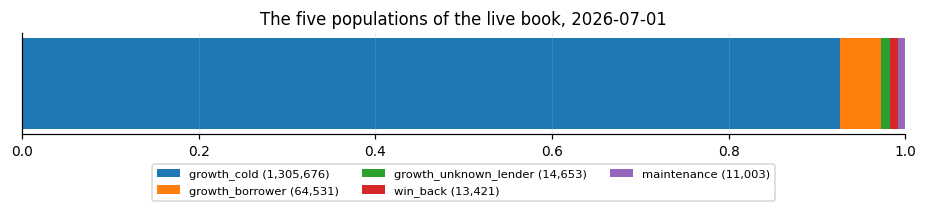

,population,companies,share
0,growth_cold,"1,305,676",92.65%
1,growth_borrower,"64,531",4.58%
2,growth_unknown_lender,"14,653",1.04%
3,win_back,"13,421",0.95%
4,maintenance,"11,003",0.78%


In [27]:
live_l = (charges.LENDER_PANEL_DIR / f"snapshot_date={panel.LAST_MONTH}" / "*.parquet").as_posix()
live_d = (panel.DELTA_DIR / f"snapshot_date={panel.LAST_MONTH}" / "*.parquet").as_posix()

pops = con.execute(f"""
    WITH live AS (
        SELECT l.* FROM read_parquet('{live_d}') p
        LEFT JOIN read_parquet('{live_l}') l USING ("CompanyNumber")
        WHERE p.is_active
    )
    SELECT CASE WHEN is_lbg_client                     THEN 'maintenance'
                WHEN ever_lbg_client                   THEN 'win_back'
                WHEN n_competitor_lenders > 0          THEN 'growth_borrower'
                WHEN n_charges_outstanding > 0         THEN 'growth_unknown_lender'
                ELSE 'growth_cold' END AS population,
           count(*) AS companies
    FROM live GROUP BY 1 ORDER BY 2 DESC
""").df()
pops["share"] = pops["companies"] / pops["companies"].sum()

fig, ax = plt.subplots(figsize=(8.5, 2.2))
left = 0
for _, r in pops.iterrows():
    ax.barh(0, r["share"], left=left, label=f"{r['population']} ({r['companies']:,})")
    left += r["share"]
ax.set_yticks([]); ax.set_xlim(0, 1)
ax.set_title(f"The five populations of the live book, {panel.LAST_MONTH}")
ax.legend(fontsize=7.5, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.25))
plt.tight_layout(); plt.show()

pops.style.format({"companies": "{:,}", "share": "{:.2%}"})

Three feeds are already on disk and need no model at all, because they are filters over the lender
panel rather than predictions: the **switch feed** (75 companies that left Lloyds for a competitor in
the last six months, with who they left for), **competitor encroachment** (115 current clients who were
Lloyds-only a year ago and have since taken a charge elsewhere, which is the early warning that gives
an RM lead time rather than a post-mortem), and **borrowing elsewhere** (already borrowing,
demonstrably fundable, not ours). They live in
`data/processed/scores/lender_feeds_2026-07.parquet`.

## 6.2 Competitor market intelligence (1.5 to 2 days)

Stop looking at companies and look at banks. 558,693 dated charges with a lender attached is a map of
UK SME secured lending, and none of it needs a model, a label, or a caveat about precision. Four
analyses, all SQL: a **league table** by sector and segment; **stock versus flow** (share of charges
outstanding against share of charges created in the trailing 12 months, where a lender whose flow share
sits below its stock share is losing ground, and no company-level view can see that); a **switching
flow matrix** from-bank by to-bank, which reuses the pairing logic already written for the switching
label and gives the Lloyds row a peer group to be judged against; and **wallet-share concentration** on
our own book.

This is the most self-contained results chapter in the project and the piece most likely to interest a
Lloyds stakeholder, because it is about them rather than about 1.4M anonymous SMEs. It goes in
`notebooks/17_*.ipynb`, and it does not depend on the model runs, so it can be written while they train.

## 6.3 Segment-wise evaluation, and a gate fixed in advance (0.5 day)

A boosted tree can already split on `is_lbg_client` and learn different rules on each side, so a
separate model per population only earns its cost if the **feature-outcome relationship** differs by
population, not merely the base rate. So I evaluate per population first (base rate, ROC-AUC,
precision@100/500, and calibration within the segment) and train a borrower-only model only if either
the recalibrated mean prediction deviates from the segment's true base rate by more than 20% relative,
or the within-segment top-10 SHAP features share fewer than 7 of 10 with the global top-10.

The gate is written down **before** seeing the numbers, and if neither condition fires I stop. That is
a result, not a failure: "the pooled model is already handling the segmentation, and here is the
evidence" is a defensible paragraph. Growth is excluded by measurement, because its base rate is flat
across all five populations (7.9% to 10.7%), so there is nothing there for specialisation to exploit.

## 6.4 What is deliberately out of scope

**Facility type and next-best-product**, measured and rejected on evidence: `classification` is
descriptive for the 319,623 pre-2013 charges, but 99.9% of the 253,142 post-2013 charges carry the
single generic label "A registered charge" and their free-text `particulars` are mostly absent, "n/a"
or "none". Companies House stopped requiring the description in 2013, so the half of the register you
cannot read is exactly the half that describes *current* holdings. That is two paragraphs in the limits
section, not a workstream, and it is why Maintenance stays the weakest of the client's three areas.

**A fifth model on `switching`.** The label is built and measured: 797 positives at quarterly origins,
a base rate of 0.53% to 0.81%. The plan set a stop rule in advance at 1,000 usable positives, and 797
is under it, so it ships as the rule-based retrospective feed above rather than as a model whose
precision@500 I could not defend. I costed the alternatives (widen to partial exits, lengthen the
horizon, both) and even the widest gives 592 training positives across three origins. The honest
version of the deliverable is a list of companies that **did** leave, measured rather than predicted.
What would change my mind, in order: another year of panel history, then monthly origins, then a
definition based on value secured rather than charge counts.

---

# 7. Status, and the two things still to run

To be completely clear about what is done and what is not, because the notebook above shows the
finished pipeline and not everything in it has been *re-run* yet.

**Done and on disk:** the 33-month panel and its parity check, the 25 delta features, the strict and
extended contract feature sets, the Charges API harvest and the thirteen lender features with all seven
verifications, the four labels, all the sampled matrices including the wider lender ones, and the
`baseline` model run recorded under `reports/runs/baseline/`.

**Still to run, and it is two lines:**

1. **The `refactor` run.** Same matrix, same 41 features, the **full** registry including the MLP. This
   is the control: it isolates "we added a model family" from "we added features", and its LightGBM and
   logistic rows should reproduce `baseline` to the digit, which doubles as proof the 27 July refactor
   changed nothing it was not meant to. `CFG = train.REFACTOR`.
2. **The `lender` run.** `model_matrix_lender/`, 54 features, three models. `CFG = train.LENDER`, then
   `train.compare_runs(["baseline", "refactor", "lender"])`. That comparison is the only thing that can
   say whether a day of harvesting bought **predictive** power, as opposed to the client-facing filters
   in section 6, which it already bought outright.

One thing to watch in the second run: if `is_lbg_client` ranks highly on `lending`, that is interesting
and slightly awkward, because it is as much a statement about who Lloyds already banks as about the
company.

After those two, in order: the strict-versus-extended contract A/B, then hyperparameter tuning (which
is pointless until the feature set stops moving, and the embargoed `OriginEmbargoSplit` machinery for
it is already written and tested), then the composite indices themselves, which are the real
deliverable: **Lending Readiness**, **Credit Risk Exposure** and **Growth Signal**, each with the top
three SHAP reasons attached per company, so the output is "this company, this score, and here are the
three things driving it" rather than an unexplained number.